In [1]:
# If needed (Colab):
# !pip -q install tensorflow scikit-learn matplotlib tqdm

import os, random
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
# Device info
print('Physical GPUs:', tf.config.list_physical_devices('GPU'))
print('Physical CPUs:', tf.config.list_physical_devices('CPU'))

Physical GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Physical CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [6]:
# MNIST
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

# Load MNIST from Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()



print('Raw train:', x_train.shape, y_train.shape, x_train.dtype)
print('Raw test :', x_test.shape,  y_test.shape,  x_test.dtype)


# Preprocess: float32, normalize [0,255] -> [0,1] -> [-1,1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
x_train = (x_train - 0.5) / 0.5
x_test  = (x_test  - 0.5) / 0.5



# Add channel dimension: (N, 28, 28) -> (N, 28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test,  -1)

# Build tf.data pipelines
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(buffer_size=len(x_train), seed=42, reshuffle_each_iteration=True)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds  = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds  = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

Raw train: (60000, 28, 28) (60000,) uint8
Raw test : (10000, 28, 28) (10000,) uint8


2026-07-25 22:08:35.207332: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Max
2026-07-25 22:08:35.207381: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 128.00 GB
2026-07-25 22:08:35.207385: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 53.76 GB
I0000 00:00:1784997515.207420 124393194 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1784997515.207467 124393194 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Batch images: (64, 28, 28, 1) | labels: [4, 4, 1, 6, 2, 2, 5, 3, 2, 0, 1, 5]
Pixel range (after normalize): -1.0 to 1.0


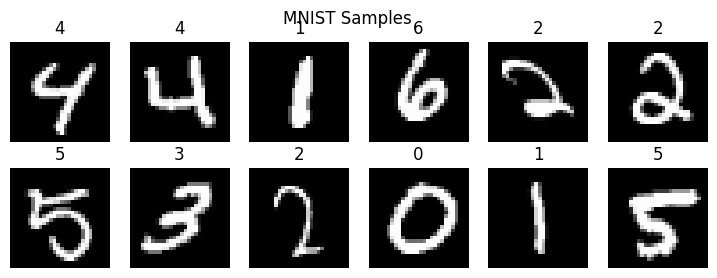

In [7]:
# Grab one batch
images, labels = next(iter(train_ds))
print('Batch images:', images.shape, '| labels:', labels[:12].numpy().tolist())
print('Pixel range (after normalize):', float(tf.reduce_min(images)), 'to', float(tf.reduce_max(images)))

fig = plt.figure(figsize=(9, 3))
for i in range(12):
    ax = fig.add_subplot(2, 6, i+1)
    ax.imshow(tf.squeeze(images[i], axis=-1), cmap='gray')
    ax.set_title(int(labels[i]))
    ax.axis('off')
plt.suptitle('MNIST Samples')
plt.show()


In [8]:
def build_mlp():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Flatten()(inputs)  
    x = layers.Dense(256, activation='relu')(x) # simple linear layer.
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    logits = layers.Dense(10)(x) 
    return keras.Model(inputs, logits, name='mlp_mnist')


model = build_mlp()
model.summary()

# Sanity-check shapes on one mini-batch
logits0 = model(images)
print('Input batch:', images.shape, '| Logits:', logits0.shape)

Model: "mlp_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

Input batch: (64, 28, 28, 1) | Logits: (64, 10)


In [9]:
model = build_mlp()
model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name='acc')]
)

EPOCHS = 30

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds,
    verbose=1
)


Epoch 1/30


2026-07-25 22:10:49.509958: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - acc: 0.4681 - loss: 1.6354 - val_acc: 0.7141 - val_loss: 0.9610
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.7717 - loss: 0.7780 - val_acc: 0.8166 - val_loss: 0.6205
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - acc: 0.8283 - loss: 0.5810 - val_acc: 0.8486 - val_loss: 0.5079
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.8525 - loss: 0.5008 - val_acc: 0.8666 - val_loss: 0.4523
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.8663 - loss: 0.4562 - val_acc: 0.8747 - val_loss: 0.4205
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - acc: 0.8745 - loss: 0.4273 - val_acc: 0.8840 - val_loss: 0.3958
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - acc: 0.8814 - loss: 0.4068 - val_acc: 0.8903 - val_loss: 0.3810
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - acc: 0.8858 - loss: 0.3919 - val_acc: 0.8927 - val_loss: 0.3662
Epoch 9/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - acc: 0.8900 -

In [17]:

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds,
    verbose=1
)

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.9123 - loss: 0.3132 - val_acc: 0.9173 - val_loss: 0.3056
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.9129 - loss: 0.3119 - val_acc: 0.9182 - val_loss: 0.3053
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - acc: 0.9131 - loss: 0.3111 - val_acc: 0.9168 - val_loss: 0.3038
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.9136 - loss: 0.3102 - val_acc: 0.9162 - val_loss: 0.3034
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.9136 - loss: 0.3094 - val_acc: 0.9168 - val_loss: 0.3025
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.9134 - loss: 0.3085 - val_acc: 0.9153 - val_loss: 0.3014
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.9141 - loss: 0.3079 - val_acc: 0.9184 - val_loss: 0.3005
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.9143 - loss: 0.3070 - val_acc: 0.9163 - val_loss: 0.3015
Epoch 9/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - ac

In [10]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [12]:
np.round(predictions[0], 2)

array([ 1.110e+00, -1.028e+01,  1.750e+00,  5.660e+00, -3.040e+00,
        4.200e-01, -8.630e+00,  1.205e+01,  1.000e-02,  3.830e+00],
      dtype=float32)

In [14]:
arg_max = np.argmax(predictions, axis=1)
arg_max[0]

np.int64(7)

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

confusion_matrix(y_test, arg_max)

array([[ 951,    0,    4,    2,    0,    8,   11,    2,    2,    0],
       [   0, 1110,    2,    3,    0,    1,    3,    2,   14,    0],
       [   7,    9,  925,   14,   14,    6,   11,   10,   31,    5],
       [   4,    1,   25,  908,    1,   33,    2,   11,   17,    8],
       [   2,    6,    5,    0,  902,    3,   13,    2,   11,   38],
       [   6,    4,    6,   39,    7,  780,   15,    7,   21,    7],
       [  11,    3,    9,    0,   11,   15,  905,    1,    3,    0],
       [   2,   11,   31,    5,   11,    2,    0,  929,    1,   36],
       [  13,    7,    7,   26,   10,   32,   14,   10,  848,    7],
       [  11,    7,    3,   12,   29,    6,    0,   25,    7,  909]])

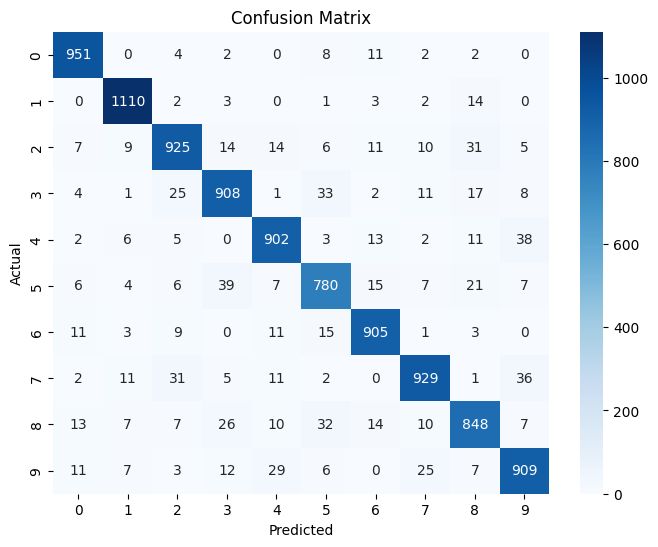

In [16]:
# plot confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, arg_max), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()